In [3]:
import pandas as pd

In [4]:
reviews = pd.read_csv("IMDB Dataset.csv")

In [5]:
print(reviews.shape)
print(reviews.head())
print(reviews.columns)

(50000, 2)
                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive
Index(['review', 'sentiment'], dtype='object')


In [6]:
import re
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

In [7]:
# Hàm tiền xử lý nhanh
def preprocess_fast(text):
    text = text.lower()
    text = re.sub(r'<.*?>', ' ', text)        # xóa HTML
    text = re.sub(r'[^a-z\s]', ' ', text)    # xóa ký tự đặc biệt/số
    text = re.sub(r'\s+', ' ', text)         # gộp khoảng trắng
    text = re.sub(r'\bnot\s+(\w+)\b', r'not_\1', text) # not good -> not_good
    words = text.split()
    words = [w for w in words if w not in ENGLISH_STOP_WORDS]
    return ' '.join(words)

In [8]:
reviews['clean_review'] = reviews['review'].apply(preprocess_fast)

In [9]:
reviews['clean_review']

,clean_review
0,reviewers mentioned watching just oz episode l...
1,wonderful little production filming technique ...
2,thought wonderful way spend time hot summer we...
3,basically s family little boy jake thinks s zo...
4,petter mattei s love time money visually stunn...
...,...
49995,thought movie did right good job wasn t creati...
49996,bad plot bad dialogue bad acting idiotic direc...
49997,catholic taught parochial elementary schools n...
49998,m going disagree previous comment maltin secon...


In [10]:
from sklearn.model_selection import train_test_split

In [11]:
X = reviews['clean_review']
y = reviews['sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [12]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [13]:
tfidf = TfidfVectorizer(stop_words='english', max_features=10000, ngram_range=(1,3))
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [14]:
import numpy as np
from sklearn.metrics import accuracy_score, classification_report
from sklearn.utils import shuffle

class SVM:
    def __init__(self, learning_rate=0.001, lambda_param=0.01):
        self.lr = learning_rate
        self.lambda_param = lambda_param
        self.w = None
        self.b = None

    def fit_batch(self, X, y):
        n_samples, n_features = X.shape
        # Khởi tạo trọng số nếu chưa có
        if self.w is None:
            self.w = np.zeros(n_features)
            self.b = 0

        # Duyệt qua từng mẫu trong batch hiện tại
        for idx, x_i in enumerate(X):
            # Tính toán điều kiện margin
            # Lưu ý: x_i * y[idx] là phép nhân vector với số
            condition = y[idx] * (np.dot(x_i, self.w) - self.b) >= 1

            if condition:
                # Nếu đoán đúng và nằm ngoài margin
                self.w -= self.lr * (2 * self.lambda_param * self.w)
            else:
                # Nếu đoán sai hoặc nằm trong margin
                self.w -= self.lr * (2 * self.lambda_param * self.w - (x_i * y[idx]))
                self.b -= self.lr * y[idx]

    def predict(self, X):
        approx = np.dot(X, self.w) - self.b
        return np.sign(approx)

# 2. Chuẩn bị dữ liệu
#print("Đang chuẩn bị dữ liệu huấn luyện...")
# Chuyển đổi nhãn sang -1 và 1
y_train_num = y_train.apply(lambda x: 1 if x == 'positive' else -1).values
y_test_num = y_test.apply(lambda x: 1 if x == 'positive' else -1).values

# 3. Huấn luyện
svm_model = SVM(learning_rate=0.01, lambda_param=0.001)

EPOCHS = 5           # Số lần học lại toàn bộ dữ liệu
BATCH_SIZE = 2000    # Kích thước gói tin
n_samples = X_train_tfidf.shape[0]

#print(f"Bắt đầu huấn luyện.")

for epoch in range(EPOCHS):
    #print(f"--- Epoch {epoch + 1}/{EPOCHS} ---")

    # QUAN TRỌNG: Xáo trộn dữ liệu đầu mỗi epoch để tránh học thuộc thứ tự
    X_shuffled, y_shuffled = shuffle(X_train_tfidf, y_train_num, random_state=epoch)

    # Chia nhỏ thành các batch để train
    for i in range(0, n_samples, BATCH_SIZE):
        # Lấy dữ liệu batch
        X_batch = X_shuffled[i : i + BATCH_SIZE]
        y_batch = y_shuffled[i : i + BATCH_SIZE]

        # Chuyển Sparse -> Dense Array (chỉ chuyển phần nhỏ này để tiết kiệm RAM)
        X_batch_dense = X_batch.toarray()

        # Cập nhật trọng số
        svm_model.fit_batch(X_batch_dense, y_batch)

#print("Huấn luyện hoàn tất!")

# ==============================================================================
# PHẦN 3: ĐÁNH GIÁ
# ==============================================================================
#print("Đang dự đoán trên tập Test...")
y_pred_num = []
n_test_samples = X_test_tfidf.shape[0]

for i in range(0, n_test_samples, BATCH_SIZE):
    X_test_batch = X_test_tfidf[i : i + BATCH_SIZE].toarray()
    batch_pred = svm_model.predict(X_test_batch)
    y_pred_num.extend(batch_pred)

y_pred_num = np.array(y_pred_num)

y_pred_str = np.where(y_pred_num == 1, 'positive', 'negative')

accuracy = accuracy_score(y_test, y_pred_str)
print(f"\nĐỘ CHÍNH XÁC: {accuracy:.4f} ({accuracy*100:.2f}%)")
print("\nBảng báo cáo chi tiết:")
print(classification_report(y_test, y_pred_str, target_names=['Negative', 'Positive']))


ĐỘ CHÍNH XÁC: 0.8400 (84.00%)

Bảng báo cáo chi tiết:
              precision    recall  f1-score   support

    Negative       0.89      0.77      0.83      4961
    Positive       0.80      0.91      0.85      5039

    accuracy                           0.84     10000
   macro avg       0.85      0.84      0.84     10000
weighted avg       0.85      0.84      0.84     10000



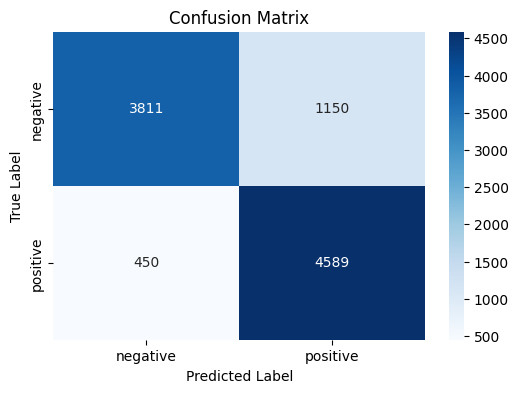

In [15]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_str, labels=["negative", "positive"])

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["negative", "positive"],
            yticklabels=["negative", "positive"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

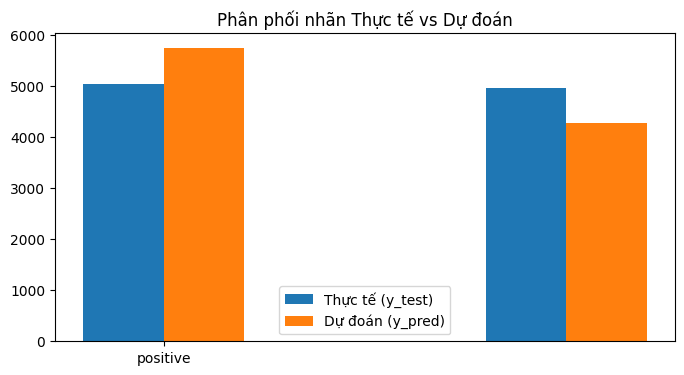

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.hist([y_test, y_pred_str], bins=3, label=["Thực tế (y_test)", "Dự đoán (y_pred)"], align='left')
plt.legend()
plt.title("Phân phối nhãn Thực tế vs Dự đoán")
plt.show()


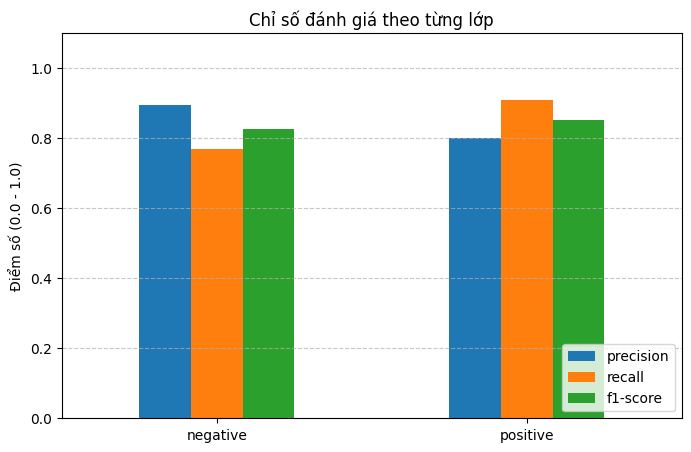

In [17]:
report = classification_report(y_test, y_pred_str, output_dict=True)
# Lấy ra negative và positive để vẽ
df_report = pd.DataFrame(report).transpose().loc[['negative', 'positive'], ['precision', 'recall', 'f1-score']]

df_report.plot(kind='bar', figsize=(8,5))
plt.title("Chỉ số đánh giá theo từng lớp")
plt.xticks(rotation=0)
plt.ylabel("Điểm số (0.0 - 1.0)")
plt.ylim(0, 1.1)
plt.legend(loc='lower right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()